In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
SIZE = 32
M = 3

In [3]:
def show_img(ax, flat_vec):
    ax.imshow(flat_vec.reshape(SIZE, SIZE), cmap='plasma', vmin=-1, vmax=1)
    ax.axis('off')

In [4]:
import art

arts, names = art.create_arts()

print("Arts shape:", arts)

selected_arts = arts[:M]

names = [name for _, name in selected_arts]
selected_arts = [art for art, _ in selected_arts]

Arts shape: [(array([-1., -1., -1., ..., -1., -1., -1.], shape=(1024,)), 'Heart'), (array([-1., -1., -1., ..., -1., -1., -1.], shape=(1024,)), 'Invader'), (array([-1., -1., -1., ..., -1., -1., -1.], shape=(1024,)), 'Pacman'), (array([-1., -1., -1., ..., -1., -1., -1.], shape=(1024,)), 'Ghost'), (array([-1., -1., -1., ..., -1., -1., -1.], shape=(1024,)), 'Yin Yang'), (array([-1., -1., -1., ..., -1., -1., -1.], shape=(1024,)), 'Mushroom'), (array([-1., -1., -1., ..., -1., -1., -1.], shape=(1024,)), 'Skull'), (array([-1., -1., -1., ..., -1., -1., -1.], shape=(1024,)), 'Tree'), (array([1., 1., 1., ..., 1., 1., 1.], shape=(1024,)), 'Creeper'), (array([-1., -1., -1., ..., -1., -1., -1.], shape=(1024,)), 'Sword')]


In [5]:
def plot_selected_arts(selected_arts, names=None):
  n = len(selected_arts)
  cols = min(n, 5)
  rows = (n + cols - 1) // cols
  fig, axs = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
  fig.suptitle("Selected Memories to train hopfield network", fontsize=16)
  for i in range(rows * cols):
      ax = axs.flat[i] if n > 1 else axs
      if i < n:
          show_img(ax, selected_arts[i])
          ax.set_title(f"{names[i] if names else f"Memory {i + 1}"}")
      else:
          ax.axis('off')
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()

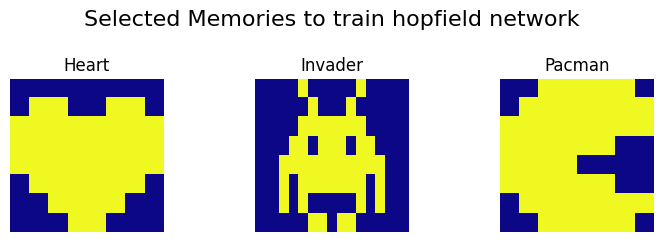

In [6]:
plot_selected_arts(selected_arts, names)

In [7]:
from ModernHopFieldNetwork import ModernHopfieldNetwork
from SimpleHopfieldNetwork import SimpleHopfieldNetwork

# net = ModernHopfieldNetwork(SIZE)
net = SimpleHopfieldNetwork(SIZE)

In [8]:
memory_matrix = net.train(selected_arts)

Learning 3 memories with 1024 neurons...
Synaptic Connections: 1,048,576 weights.


In [9]:
memory_matrix

array([[0.        , 0.00292969, 0.00292969, ..., 0.00292969, 0.00292969,
        0.00292969],
       [0.00292969, 0.        , 0.00292969, ..., 0.00292969, 0.00292969,
        0.00292969],
       [0.00292969, 0.00292969, 0.        , ..., 0.00292969, 0.00292969,
        0.00292969],
       ...,
       [0.00292969, 0.00292969, 0.00292969, ..., 0.        , 0.00292969,
        0.00292969],
       [0.00292969, 0.00292969, 0.00292969, ..., 0.00292969, 0.        ,
        0.00292969],
       [0.00292969, 0.00292969, 0.00292969, ..., 0.00292969, 0.00292969,
        0.        ]], shape=(1024, 1024))

In [10]:
def break_art_and_flattern(art, size=SIZE):
    """Takes a 32x32 art and breaks it in half"""
    # We take the Invader and WIPE OUT the right half
    input_broken = art.copy()
    reshaped = input_broken.reshape(SIZE, SIZE)
    reshaped[:, SIZE//2:] = -1 # Erase right half (set to background)
    plt.imshow(reshaped, cmap="plasma")
    plt.title("Broken Art")
    plt.show()
    input_broken = reshaped.flatten()
    return input_broken

In [11]:
import numpy as np

def break_continuous_art(art, size=128, damage_type="alternating_right"):
    """
    Corrupts a continuous (grayscale) image.
    args:
        art: Flattened numpy array of the image
        size: Width/Height of the image
        damage_type: 'mask_right', 'mask_center', 'static', or 'alternating_right'
        
        - 'mask_right': zero out right half
        - 'mask_center': black out center square
        - 'static': add gaussian noise
        - 'alternating_right': alternate rows on right half set to 0
    """
    # 1. Reshape to 2D so we can manipulate regions
    input_broken = art.copy().reshape(size, size)
    
    if damage_type == "mask_right":
        # WIPE OUT the right half (Set to 0.0 or -1.0 depending on your data range)
        # We use 0.0 (Gray) here as a "neutral" missing value
        input_broken[:, size//2:] = 0.0 
        
    elif damage_type == "mask_center":
        # Put a black box in the middle
        margin = size // 4
        input_broken[margin:-margin, margin:-margin] = -1.0
        
    elif damage_type == "static":
        # Add Gaussian Noise (The most common continuous test)
        noise = np.random.normal(0, 0.4, (size, size)) # Mean 0, Sigma 0.4
        input_broken = input_broken + noise
        # Clip to keep values valid (e.g., between -1 and 1)
        input_broken = np.clip(input_broken, -1.0, 1.0)

    elif damage_type == "alternating_right":
        # Left half stays the same, right half: set alternate rows to 0
        # Loop through each row: for even rows (or odd, your choice), set right half to 0
        for row in range(size):
            if row % 2 == 0:
                input_broken[row, size//2:] = 0.0

    # 2. Flatten back to vector
    return input_broken.flatten()

In [12]:
def attempt_restore_memory(
        selected_arts,
        nameorindex,
        steps=50,
        names=[],
        net: ModernHopfieldNetwork | SimpleHopfieldNetwork | None = None,
        continuous=False,
        damage_type="alternating_right"
    ):
    if net is None:
        net = ModernHopfieldNetwork(SIZE)
        net.train(selected_arts)
    result = {}
    if isinstance(nameorindex, int):
        art = selected_arts[nameorindex]
    else:
        art = selected_arts[names.index(nameorindex)]
        name = nameorindex
        result["name"] = name
    broken_and_flattened = break_art_and_flattern(art) if not continuous else break_continuous_art(art, damage_type=damage_type)
    restoration = net.restore_memory(broken_and_flattened, art, steps=steps)
    restoration.plot_restoration()
    return restoration

In [13]:
names

['Heart', 'Invader', 'Pacman']

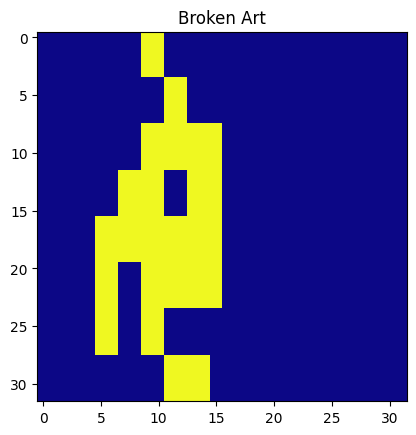

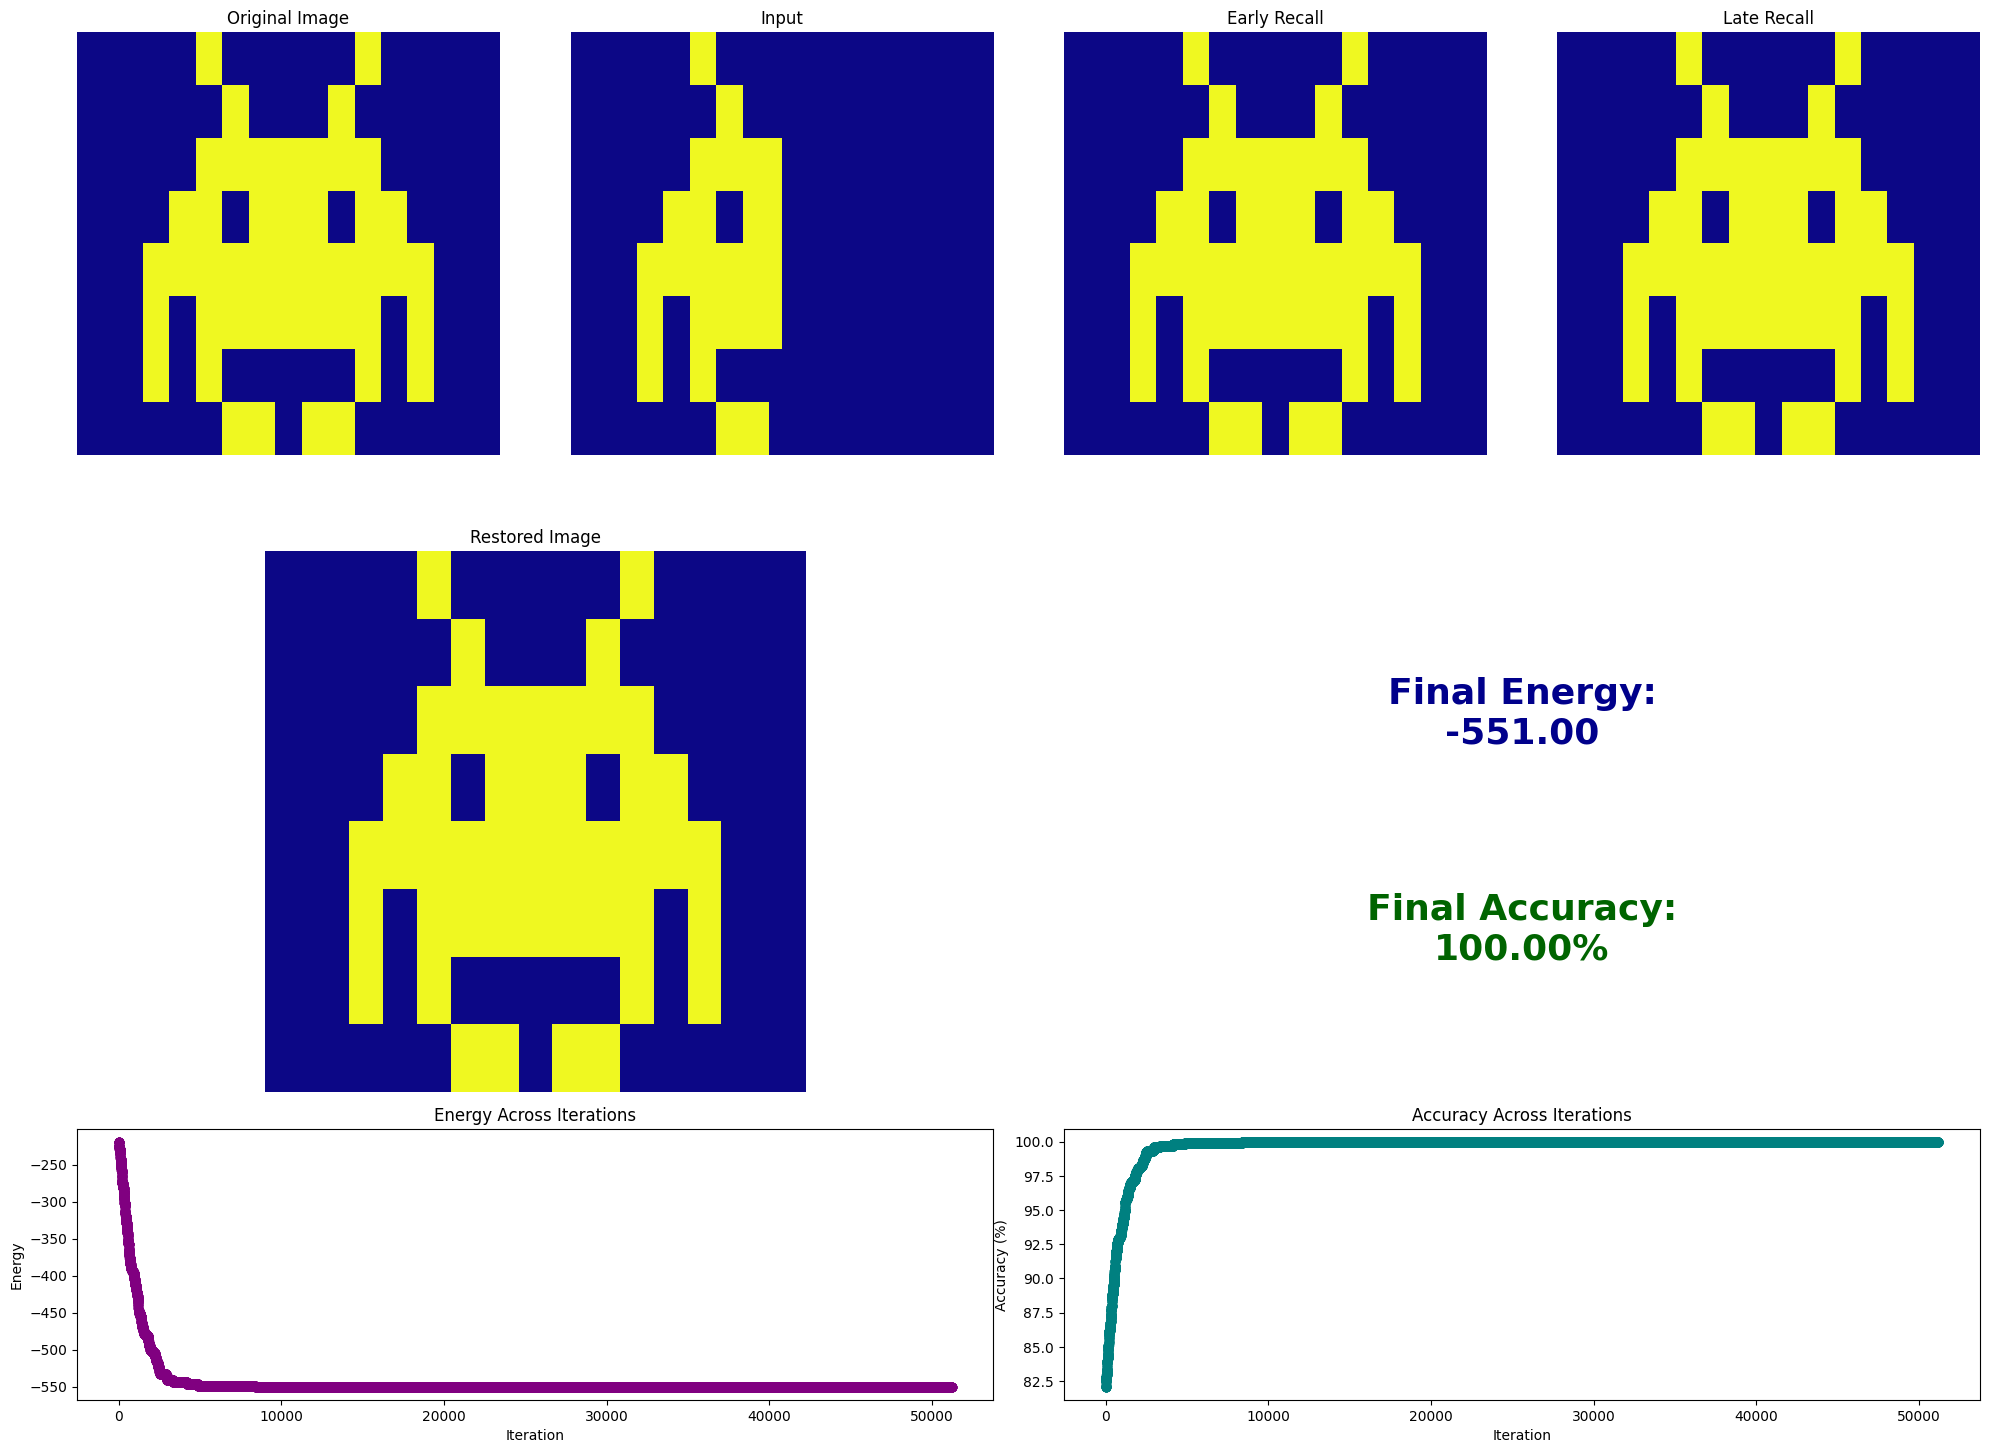

In [14]:
result = attempt_restore_memory(selected_arts, "Invader", names=names, net=net)

### Let's try with random static patterns

Learning 10 memories with 1024 neurons...
Synaptic Connections: 1,048,576 weights.


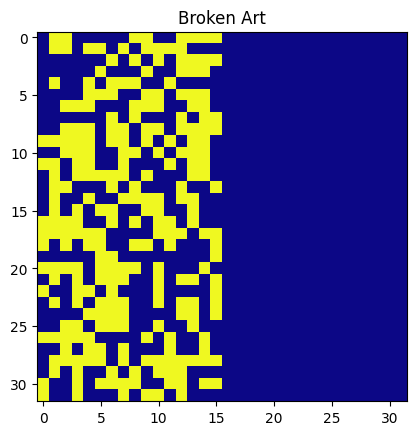

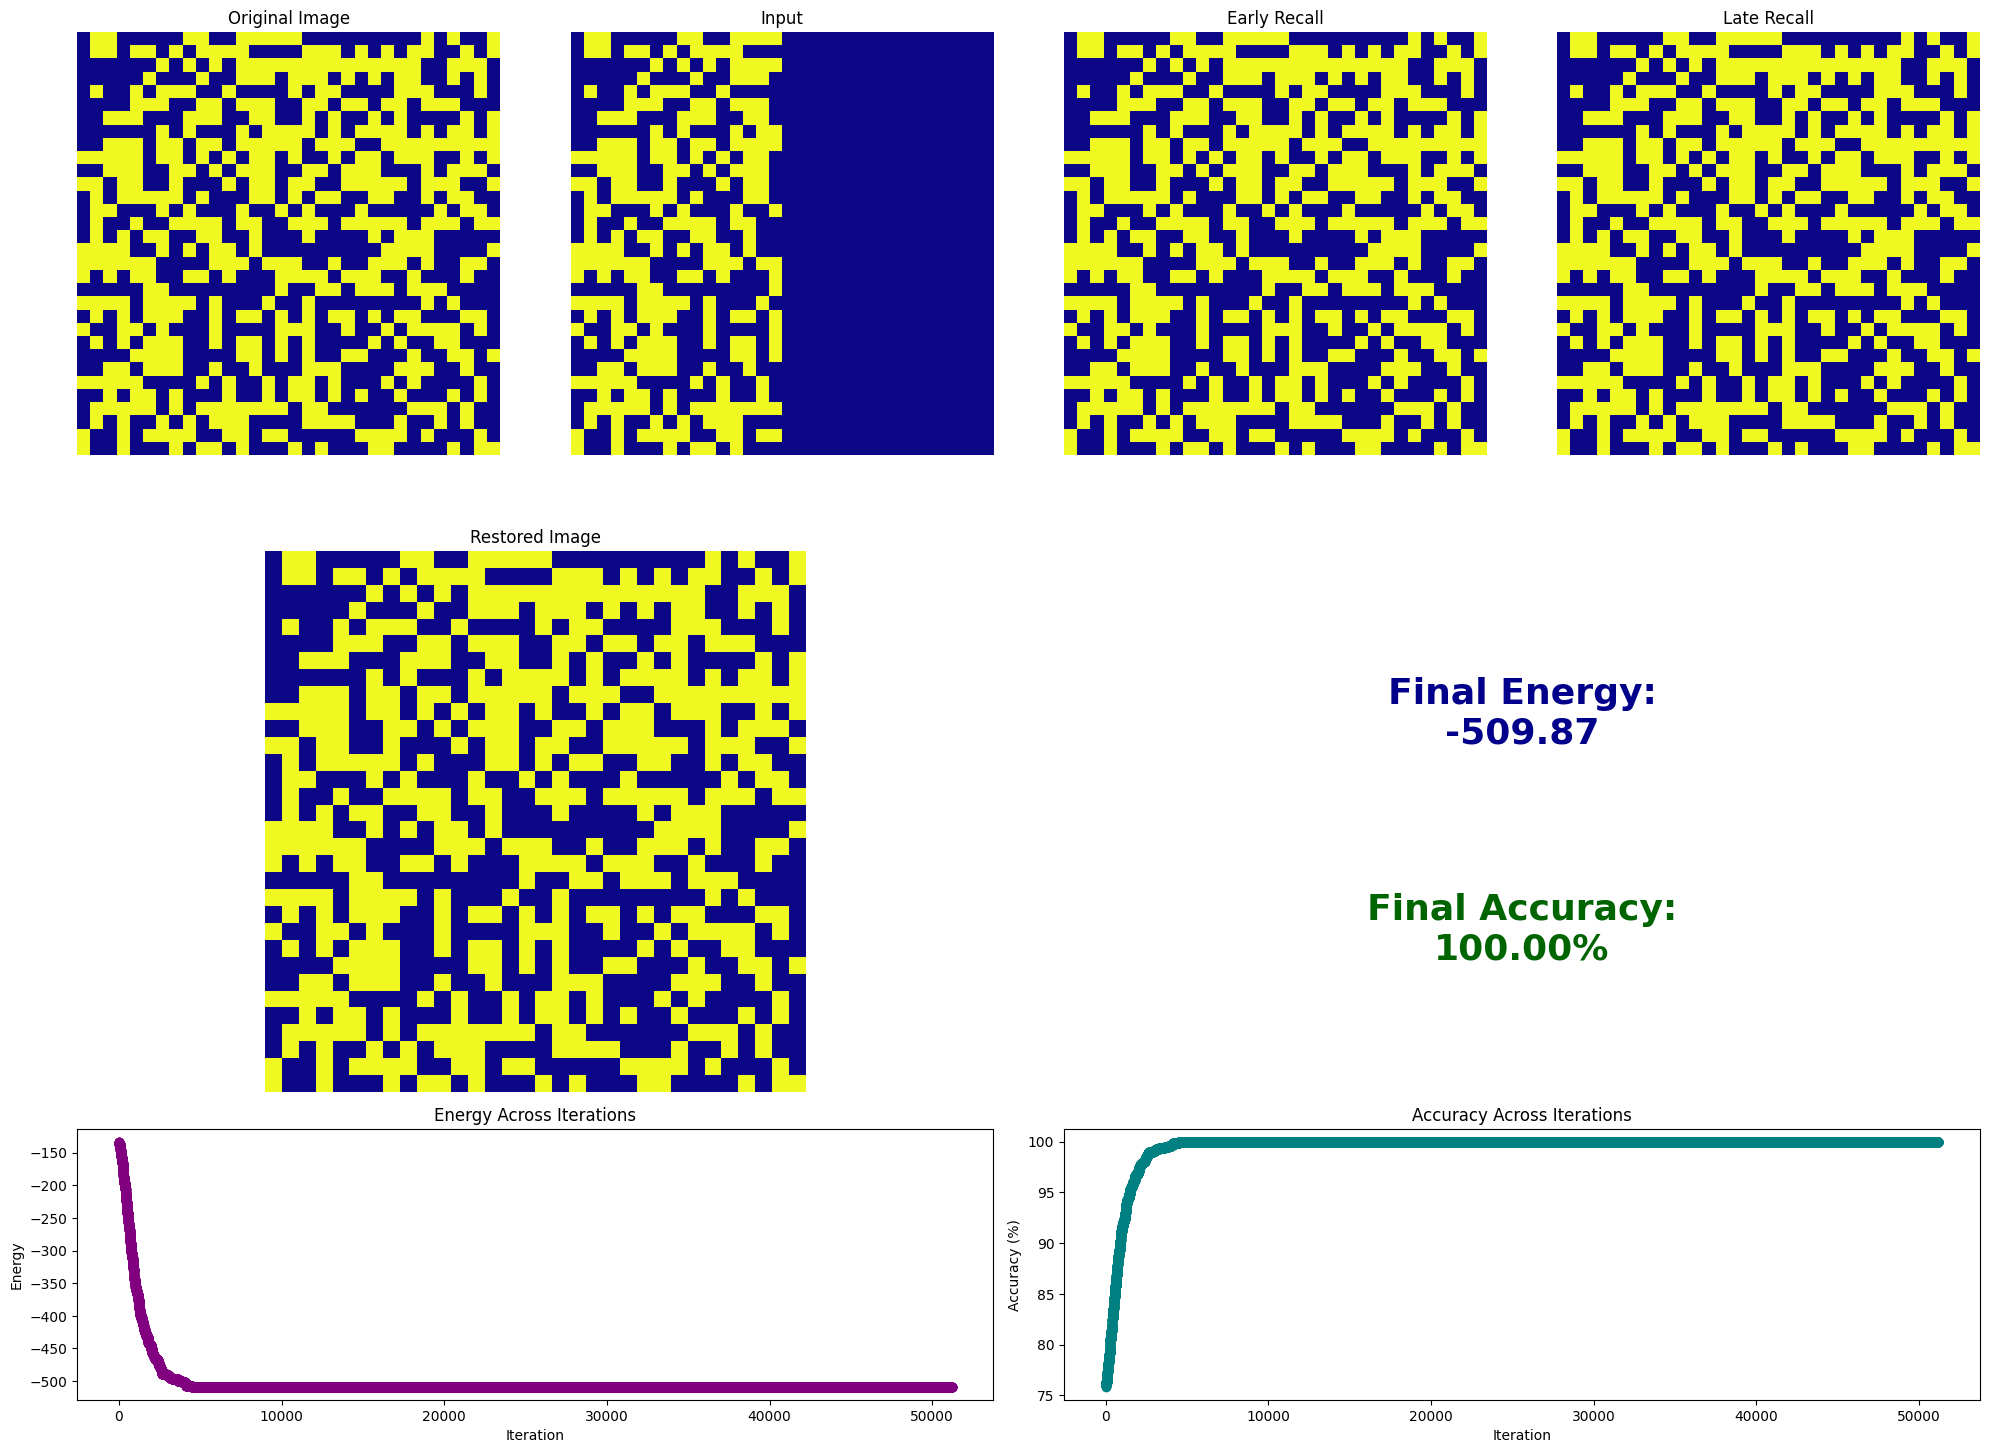

In [15]:
random_static_images = art.get_random_binary_images(SIZE, 10)
net = SimpleHopfieldNetwork(SIZE)
net.train(random_static_images)
result = attempt_restore_memory(random_static_images, 0, net=net, damage_type="static")

In [16]:
random_static_images[0].shape

(1024,)

### Let's test with random images

In [17]:
SIZE = 128

In [18]:
import os
from PIL import Image
import numpy as np

# Path to assets directory
assets_folder = "assets"

images = []
for filename in os.listdir(assets_folder):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
        image_path = os.path.join(assets_folder, filename)
        img = Image.open(image_path).convert("L").resize((128, 128))
        img_array = np.array(img)
        images.append(img_array.flatten())

images = np.array(images)  # Shape: (num_images, 128, 128)


In [19]:
images[0].shape

(16384,)

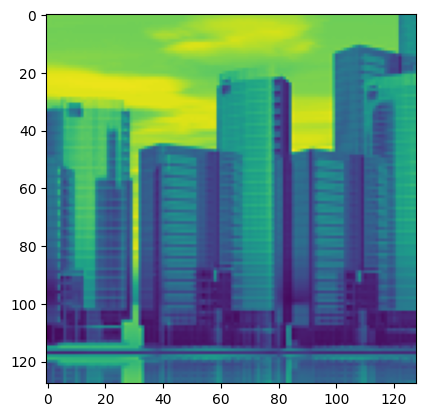

In [20]:
plt.imshow(images[0].reshape(128, 128))

In [ ]:
from ModernHopFieldNetwork import ModernHopfieldNetwork
from SimpleHopfieldNetwork import SimpleHopfieldNetwork

net = ModernHopfieldNetwork(SIZE, binary=False, beta=100)

In [ ]:
net.train_normalized(images)

Learning 19 memories with 16384 neurons...
Synaptic Connections: 268,435,456 weights.


array([[0.        , 0.18304443, 0.1328125 , ..., 0.09771729, 0.15393066,
        0.11608887],
       [0.18304443, 0.        , 0.13269043, ..., 0.14941406, 0.1696167 ,
        0.12640381],
       [0.1328125 , 0.13269043, 0.        , ..., 0.14337158, 0.11688232,
        0.12585449],
       ...,
       [0.09771729, 0.14941406, 0.14337158, ..., 0.        , 0.17834473,
        0.13336182],
       [0.15393066, 0.1696167 , 0.11688232, ..., 0.17834473, 0.        ,
        0.15618896],
       [0.11608887, 0.12640381, 0.12585449, ..., 0.13336182, 0.15618896,
        0.        ]], shape=(16384, 16384))

In [23]:
result = attempt_restore_memory(images, 0, net=net, continuous=True, damage_type="mask_right")

KeyboardInterrupt: 